In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/rwalden-gif/IntroToML/main/D3.csv'
data = pd.read_csv(url)

X1 = data["X1"].values
X2 = data["X2"].values
X3 = data["X3"].values
Y  = data["Y"].values
m = len(Y)

print(data.head())
print("Number of samples:", m)


         X1        X2        X3         Y
0  0.000000  3.440000  0.440000  4.387545
1  0.040404  0.134949  0.888485  2.679650
2  0.080808  0.829899  1.336970  2.968490
3  0.121212  1.524848  1.785455  3.254065
4  0.161616  2.219798  2.233939  3.536375
Number of samples: 100


In [ ]:
def gradient_descent(X, y, alpha=0.05, iterations=1000)
    m = len(y)
    X_b = np.c_[np.ones(m), X]
    n = X_b.shape[1]
    theta = np.zeros(n)
    cost_history = []

    for it in range(iterations):
        predictions = X_b.dot(theta)
        errors = predictions - y
        gradient = (1/m) * X_b.T.dot(errors)
        theta = theta - alpha * gradient
        cost = (1/(2*m)) * np.sum(errors**2)
        cost_history.append(cost)

    return theta, cost_history


In [ ]:
learning_rates = [0.1, 0.05, 0.01]
iterations = 1000
variables = {"X1": X1, "X2": X2, "X3": X3}

results_p1 = {}

for name, x in variables.items():
    print(f"{name}")
    best_alpha, best_theta, best_cost_hist = None, None, None

    for alpha in learning_rates:
        theta, cost_hist = gradient_descent(x.reshape(-1,1), Y, alpha=alpha, iterations=iterations)
        print(f"alpha={alpha}: final cost={cost_hist[-1]:.5f}, theta0={theta[0]:.4f}, theta1={theta[1]:.4f}")

        if best_cost_hist is None or cost_hist[-1] < best_cost_hist[-1]:
            best_alpha, best_theta, best_cost_hist = alpha, theta, cost_hist

    results_p1[name] = (best_alpha, best_theta, best_cost_hist, x)
    print(f">> Best for {name}: alpha={best_alpha}, model: Y = {best_theta[0]:.4f} + {best_theta[1]:.4f}*{name}")


X1
alpha=0.1: final cost=0.98499, theta0=5.9279, theta1=-2.0383
alpha=0.05: final cost=0.98499, theta0=5.9279, theta1=-2.0383
alpha=0.01: final cost=1.03666, theta0=5.2929, theta1=-1.7912
>> Best for X1: alpha=0.1, model: Y = 5.9279 + -2.0383*X1
X2
alpha=0.1: final cost=3.59937, theta0=0.7361, theta1=0.5576
alpha=0.05: final cost=3.59937, theta0=0.7361, theta1=0.5576
alpha=0.01: final cost=3.59967, theta0=0.6870, theta1=0.5767
>> Best for X2: alpha=0.1, model: Y = 0.7361 + 0.5576*X2
X3
alpha=0.1: final cost=3.62945, theta0=2.8714, theta1=-0.5205
alpha=0.05: final cost=3.62945, theta0=2.8714, theta1=-0.5205
alpha=0.01: final cost=3.63971, theta0=2.5912, theta1=-0.4097
>> Best for X3: alpha=0.1, model: Y = 2.8714 + -0.5205*X3


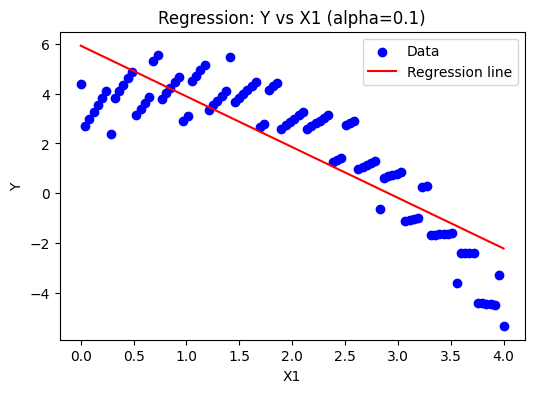

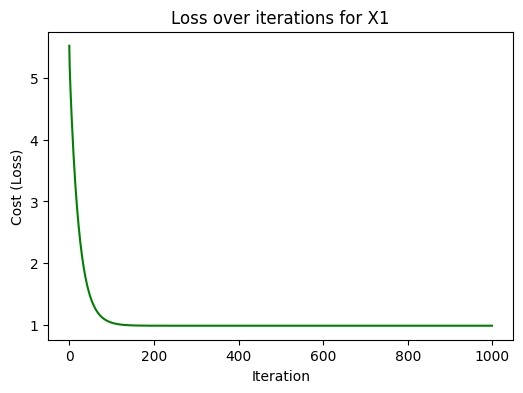

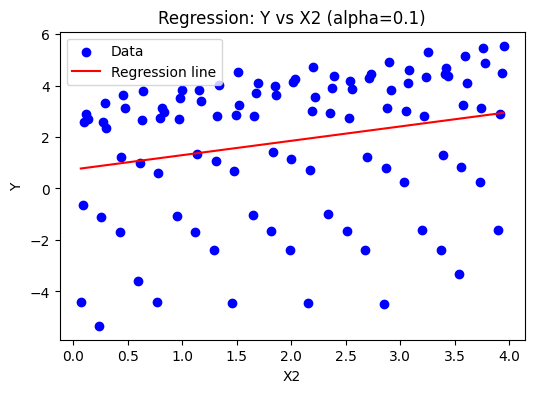

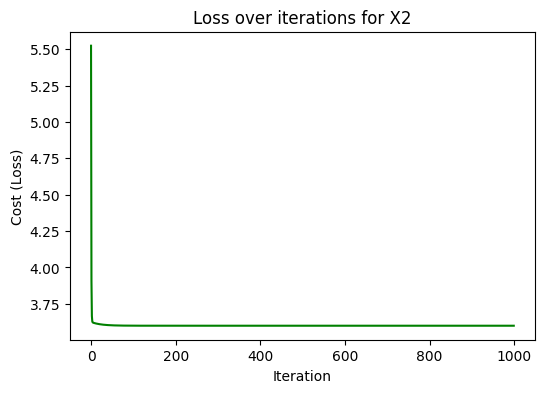

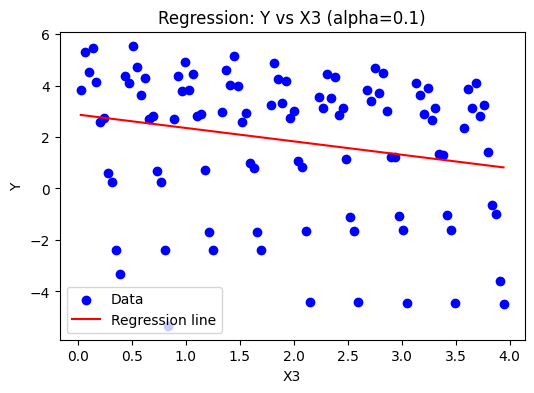

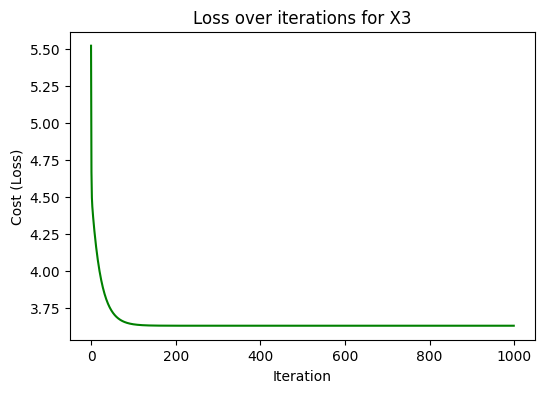

X1: final loss = 0.98499
X2: final loss = 3.59937
X3: final loss = 3.62945


In [ ]:
for name, (alpha, theta, cost_hist, x) in results_p1.items():

  plt.figure(figsize=(6,4.5))
  plt.scatter(x, Y, color="blue", label="Data")
  x_sorted = np.sort(x)
  y_pred = theta[0] + theta[1]*x_sorted
  plt.plot(x_sorted, y_pred, color="red", label="Regression line")
  plt.xlabel(name)
  plt.ylabel("Y")
  plt.title(f"{name} vs Y")
  plt.legend()
  plt.show()

  plt.figure(figsize=(6,4.5))
  plt.plot(range(len(cost_hist)), cost_hist, color="green")
  plt.xlabel("Iteration")
  plt.ylabel("Cost (Loss)")
  plt.title(f"Loss Curve for {name}")
  plt.show()


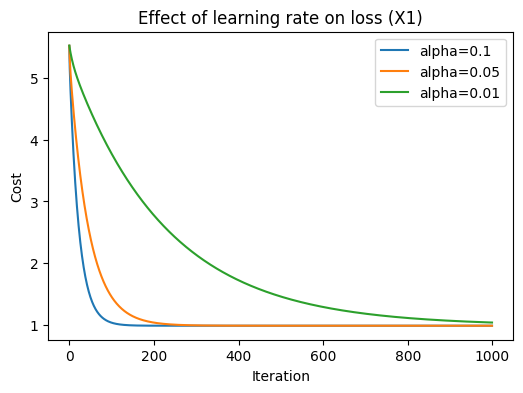

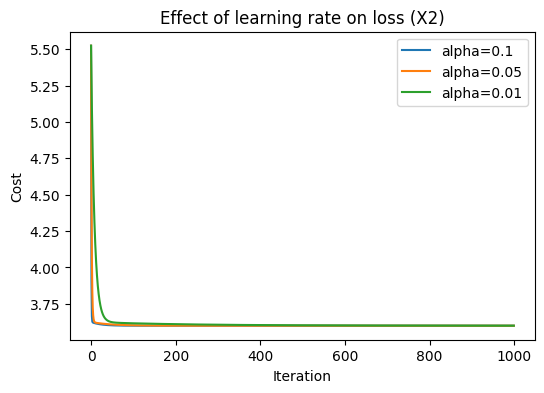

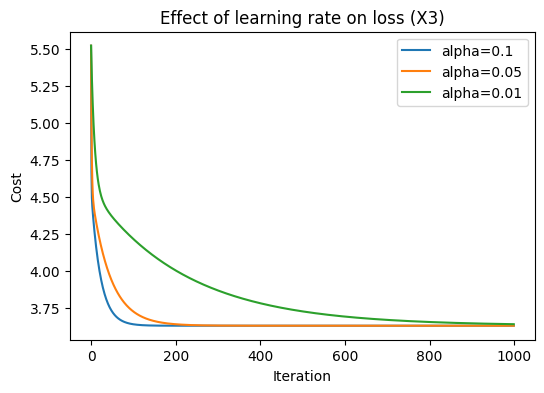

In [ ]:
for name, x in variables.items():
    plt.figure(figsize=(6,4))
    for alpha in learning_rates:
        _, cost_hist = gradient_descent(x.reshape(-1,1), Y, alpha=alpha, iterations=iterations)
        plt.plot(cost_hist, label=f"alpha={alpha}")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title(f"Effect of learning rate on loss ({name})")
    plt.legend()
    plt.show()


In [ ]:
final_costs = {}
for name, (alpha, theta, cost_hist, x) in results_p1.items():
  final_costs[name] = cost_hist[-1]
  print(f"{name}: final loss = {cost_hist[-1]:.5f}")

plt.figure(figsize=(6,4.5))
plt.bar(final_costs.keys(), final_costs.values(), color=["#4C72B0","#DD8452","#55A868"])
plt.ylabel("Final Cost")
plt.title("Final Cost by Variable")
for i, (k, v) in enumerate(final_costs.items()):
  plt.text(i, v+0.05, f"{v:.3f}", ha="center")
plt.show()

In [ ]:
X_multi = np.column_stack((X1, X2, X3))



best_alpha2, best_theta2, best_cost2 = None, None, None

for alpha in learning_rates_p2:
    theta, cost_hist = gradient_descent(X_multi, Y, alpha=alpha, iterations=iterations_p2)
    print(f"alpha={alpha} final cost={cost_hist[-1]:.5f}, theta={theta}")
    if best_cost2 is None or cost_hist[-1] < best_cost2[-1]:
        best_alpha2, best_theta2, best_cost2 = alpha, theta, cost_hist

theta_multi = best_theta2
cost_hist_multi = best_cost2

print(f"\nBest alpha: {best_alpha2}")
print(f"Final model: Y = {best_theta2[0]:.4f} + {best_theta2[1]:.4f}*X1 + {best_theta2[2]:.4f}*X2 + {best_theta2[3]:.4f}*X3")
print(f"Final cost: {cost_hist_multi[-1]:.5f}")


alpha=0.1 final cost 0.73846, theta [ 5.31393577 -2.00368658  0.53260157 -0.26556795]
alpha=0.05 final cost 0.73853, theta [ 5.27907019 -1.99876124  0.53836289 -0.26045736]
alpha=0.01 final cost 0.93417, theta [ 3.39929705 -1.73320582  0.84898275  0.0150737 ]

Best alpha: 0.1
Final model: Y = 5.3139 + -2.0037*X1 + 0.5326*X2 + -0.2656*X3


In [ ]:
plt.figure(figsize=(6,4.5))
for alpha in learning_rates:
_, cost_hist = gradient_descent(X_multi, Y, alpha, iterations)
plt.plot(cost_hist, label=f"alpha={alpha}")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Learning Rate Comparison for the Full Model")
plt.legend()
plt.show()

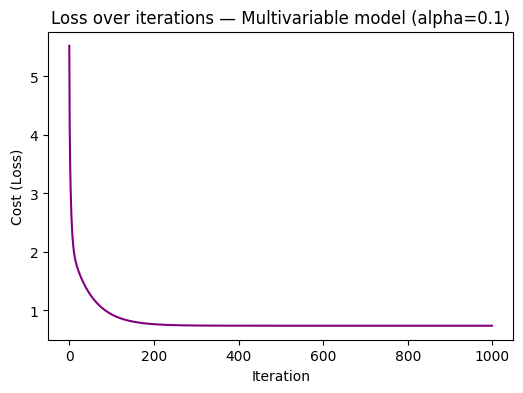

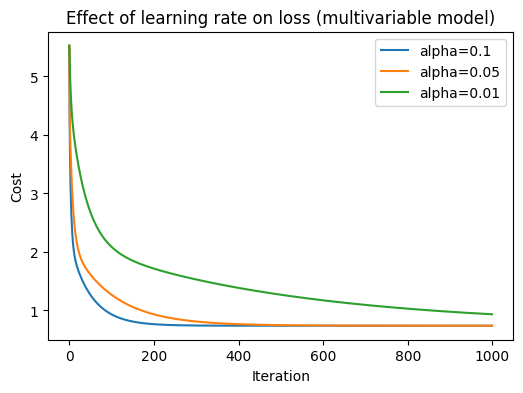

In [ ]:
plt.figure(figsize=(6,4.5))
plt.plot(cost_hist_multi, color="purple")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Loss Curve for the Full Model")
plt.show()


In [ ]:
new_points = [(1,1,1), (2,0,4), (3,2,1)]

for (x1, x2, x3) in new_points:
  y_pred = theta_multi[0] + theta_multi[1]*x1 + theta_multi[2]*x2 + theta_multi[3]*x3
  print(f"Prediction for (X1={x1}, X2={x2}, X3={x3}): Y = {y_pred:.4f}")


Prediction for (X1=1, X2=1, X3=1): Y = 3.5773
Prediction for (X1=2, X2=0, X3=4): Y = 0.2443
Prediction for (X1=3, X2=2, X3=1): Y = 0.1025
